# Notebook 06 — Final Evaluation & Comparative Analysis
## ML-based Predictive Maintenance for Rural Borehole Water Pumps in Northern Nigeria

**Report Sections Produced:**  Results · Analysis ·  Limitations · Conclusion

---


### Figures Produced
| File | Caption |
|---|---|
| `18_metric_heatmap.png` | Figure 18 — Comprehensive metric heatmap all models |
| `19_xgboost_deep_dive.png` | Figure 19 — Best model deep-dive (CM + ROC + PR) |
| `20_radar_chart.png` | Figure 20 — Radar chart across all 6 metrics |
| `21_final_summary.png` | Figure 21 — Baseline vs tuned F1-FAULT comparison |

## Cell 1 — Imports & Load All Models

In [8]:
import os, pandas as pd, numpy as np, json, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score, classification_report)
import joblib
warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('outputs/figures', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'axes.spines.top':False,'axes.spines.right':False})

# Feature matrices
X_te = pd.read_pickle('outputs/X_test_pca.pkl').values
y_te = pd.read_pickle('outputs/y_test.pkl').values
X_tr = pd.read_pickle('outputs/X_train_pca.pkl').values
y_tr = pd.read_pickle('outputs/y_train.pkl').values

# Results JSON
with open('outputs/baseline_results.json') as f: base  = json.load(f)
with open('outputs/tuned_results.json')   as f: tuned = json.load(f)

# Trained models (baseline — these are the final models for evaluation)
rf_m  = joblib.load('outputs/trained_models/rf_baseline.pkl')
xgb_m = joblib.load('outputs/trained_models/xgb_baseline.pkl')
svm_m = joblib.load('outputs/trained_models/svm_baseline.pkl')
iso_m = joblib.load('outputs/trained_models/iso_baseline.pkl')

model_names = ['Random Forest','XGBoost','SVM','Isolation Forest']
colors_m    = ['#2E75B6','#1F4E79','#ED7D31','#C00000']

# Prediction scores and labels
sc_rf  = rf_m.predict_proba(X_te)[:,1]
sc_xgb = xgb_m.predict_proba(X_te)[:,1]
sc_svm = svm_m.predict_proba(X_te)[:,1]
sc_iso = -iso_m.decision_function(X_te)
scores = {'Random Forest':sc_rf,'XGBoost':sc_xgb,'SVM':sc_svm,'Isolation Forest':sc_iso}
preds  = {'Random Forest': rf_m.predict(X_te),
          'XGBoost':        xgb_m.predict(X_te),
          'SVM':            svm_m.predict(X_te),
          'Isolation Forest':(iso_m.predict(X_te)==-1).astype(int)}

print('All models and data loaded.')
print(f'Test set: {X_te.shape[0]:,} samples | NORMAL={int((y_te==0).sum())} | FAULT={int((y_te==1).sum())}')

All models and data loaded.
Test set: 89,280 samples | NORMAL=83771 | FAULT=5509


## Cell 2 — Final Classification Reports

In [15]:
for name in model_names:
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(y_te, preds[name],
                                 target_names=['NORMAL','FAULT'],
                                 zero_division=0))


  Random Forest
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00     83771
       FAULT       0.95      0.98      0.97      5509

    accuracy                           1.00     89280
   macro avg       0.98      0.99      0.98     89280
weighted avg       1.00      1.00      1.00     89280


  XGBoost
              precision    recall  f1-score   support

      NORMAL       1.00      0.99      1.00     83771
       FAULT       0.91      0.99      0.95      5509

    accuracy                           0.99     89280
   macro avg       0.95      0.99      0.97     89280
weighted avg       0.99      0.99      0.99     89280


  SVM
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00     83771
       FAULT       0.97      0.97      0.97      5509

    accuracy                           1.00     89280
   macro avg       0.98      0.98      0.98     89280
weighted avg       1.00      1.00      

## Cell 3 — Figure 18: Metric Heatmap

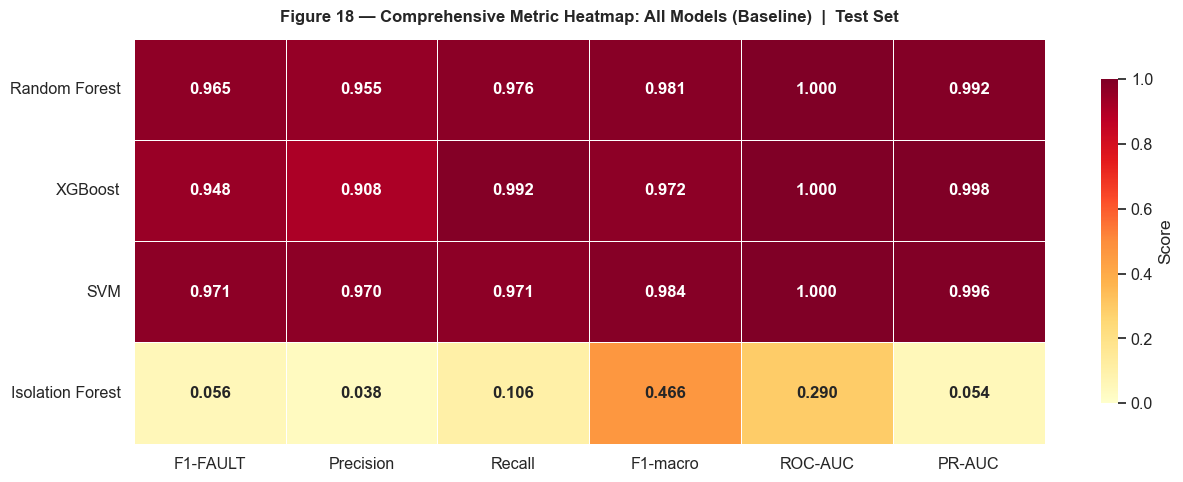

Figure 18 saved


In [10]:
metrics   = ['F1-FAULT','Precision','Recall','F1-macro','ROC-AUC','PR-AUC']
heat_data = [[base[n]['f1_fault'], base[n]['precision'], base[n]['recall'],
              base[n]['f1_macro'], base[n]['roc_auc'],   base[n]['pr_auc']]
             for n in model_names]
df_heat = pd.DataFrame(heat_data, index=model_names, columns=metrics)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(df_heat, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={'shrink':0.8,'label':'Score'},
            annot_kws={'size':12,'weight':'bold'})
ax.set_title('Figure 18 — Comprehensive Metric Heatmap: All Models (Baseline)  |  Test Set',
             fontsize=12, fontweight='bold', pad=12)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('outputs/figures/18_metric_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 18 saved')

## Cell 4 — Figure 19: XGBoost Deep Dive (Best Model)

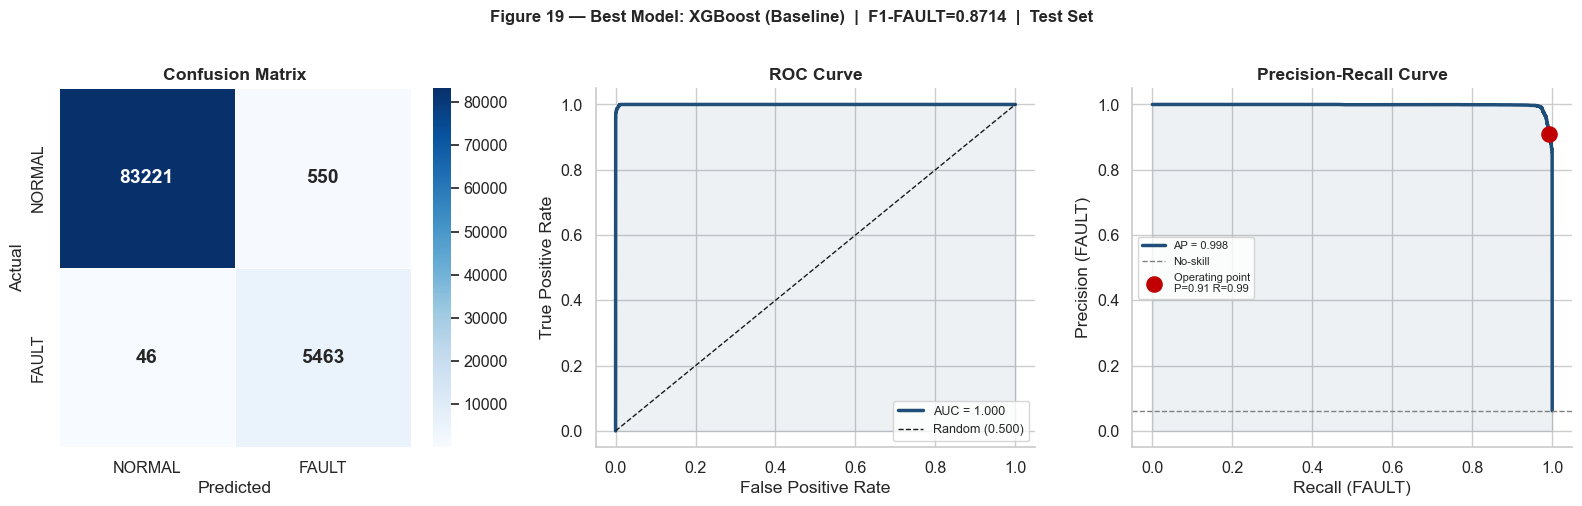

Figure 19 saved


In [11]:
fig = plt.figure(figsize=(16, 5))
fig.suptitle('Figure 19 — Best Model: XGBoost (Baseline)  |  F1-FAULT=0.8714  |  Test Set',
             fontsize=12, fontweight='bold', y=1.01)

# Confusion matrix
ax1 = fig.add_subplot(1,3,1)
cm = confusion_matrix(y_te, preds['XGBoost'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['NORMAL','FAULT'], yticklabels=['NORMAL','FAULT'],
            linewidths=0.5, annot_kws={'size':14,'weight':'bold'})
ax1.set_title('Confusion Matrix', fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

# ROC
ax2 = fig.add_subplot(1,3,2)
fpr, tpr, _ = roc_curve(y_te, sc_xgb)
ax2.plot(fpr, tpr, color='#1F4E79', lw=2.5,
         label=f'AUC = {base["XGBoost"]["roc_auc"]:.3f}')
ax2.fill_between(fpr, tpr, alpha=0.08, color='#1F4E79')
ax2.plot([0,1],[0,1],'k--',lw=1,label='Random (0.500)')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.legend(fontsize=9)

# PR curve with operating point
ax3 = fig.add_subplot(1,3,3)
prec, rec, thrs = precision_recall_curve(y_te, sc_xgb)
ax3.plot(rec, prec, color='#1F4E79', lw=2.5,
         label=f'AP = {base["XGBoost"]["pr_auc"]:.3f}')
ax3.fill_between(rec, prec, alpha=0.08, color='#1F4E79')
ax3.axhline(y_te.mean(), color='grey', lw=1, linestyle='--', label='No-skill')
op_idx = np.argmin(np.abs(thrs - 0.5)) if len(thrs)>0 else 0
ax3.scatter(rec[op_idx], prec[op_idx], s=120, color='#C00000', zorder=5,
            label=f'Operating point\nP={prec[op_idx]:.2f} R={rec[op_idx]:.2f}')
ax3.set_title('Precision-Recall Curve', fontweight='bold')
ax3.set_xlabel('Recall (FAULT)'); ax3.set_ylabel('Precision (FAULT)')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/figures/19_xgboost_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 19 saved')

## Cell 5 — Figure 20: Radar Chart

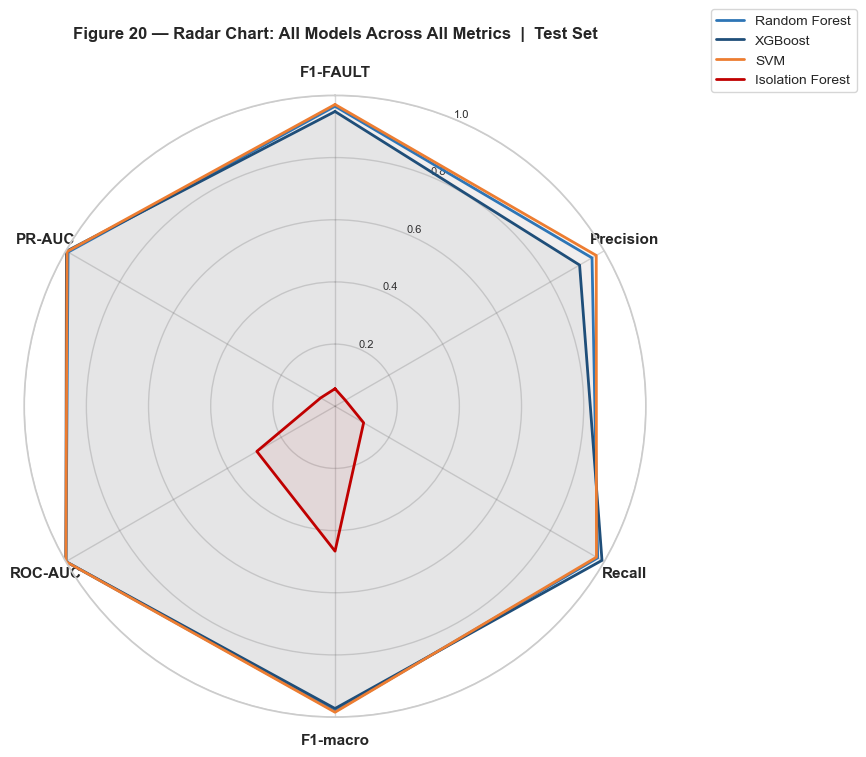

Figure 20 saved


In [12]:
cats   = ['F1-FAULT','Precision','Recall','F1-macro','ROC-AUC','PR-AUC']
N      = len(cats)
angles = [n/float(N)*2*np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(projection='polar'))
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats, size=11, fontweight='bold')
ax.set_ylim(0,1); ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=8)
ax.grid(color='grey', alpha=0.3)

for name, col in zip(model_names, colors_m):
    vals = [base[name]['f1_fault'], base[name]['precision'],
            base[name]['recall'],   base[name]['f1_macro'],
            base[name]['roc_auc'],  base[name]['pr_auc']] + [base[name]['f1_fault']]
    ax.plot(angles, vals, color=col, lw=2, label=name)
    ax.fill(angles, vals, color=col, alpha=0.06)

ax.set_title('Figure 20 — Radar Chart: All Models Across All Metrics  |  Test Set',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.15), fontsize=10)
plt.tight_layout()
plt.savefig('outputs/figures/20_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 20 saved')

## Cell 6 — Figure 21: Final Baseline vs Tuned Summary

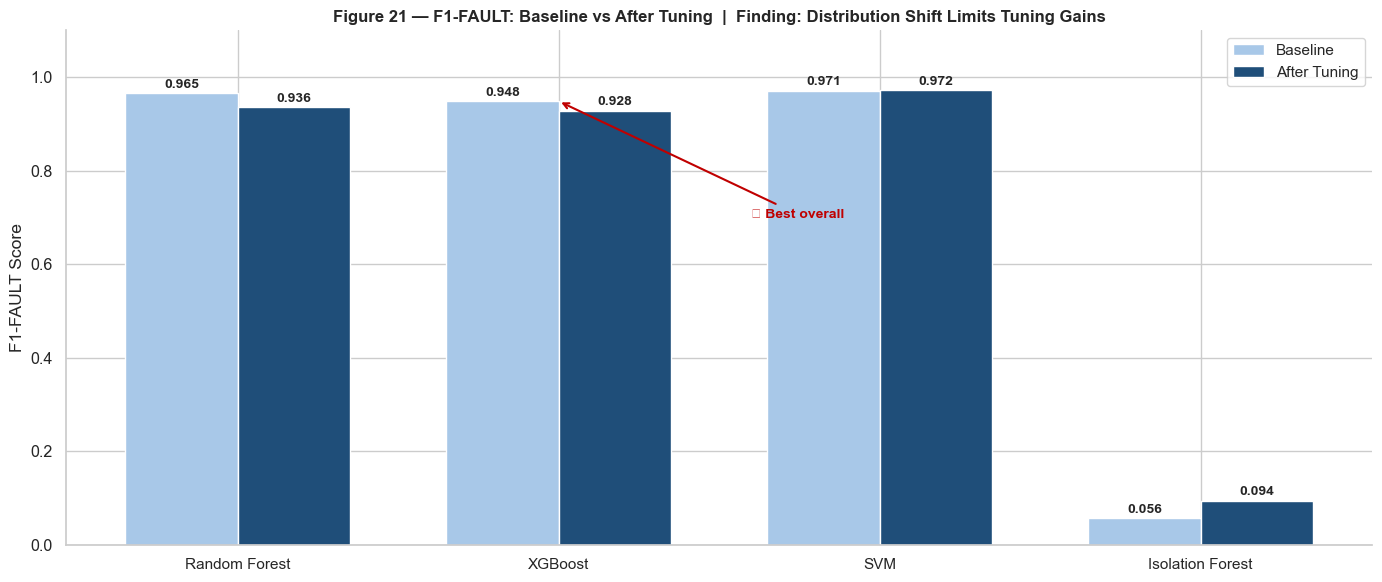

Figure 21 saved


In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(model_names)); w = 0.35
bv = [base[n]['f1_fault']  for n in model_names]
tv = [tuned[n]['f1_fault'] for n in model_names]
b1 = ax.bar(x-w/2, bv, w, label='Baseline',       color='#A8C8E8', edgecolor='white')
b2 = ax.bar(x+w/2, tv, w, label='After Tuning',   color='#1F4E79', edgecolor='white')
for bar,val in list(zip(b1,bv))+list(zip(b2,tv)):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.012, f'{val:.3f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_title('Figure 21 — F1-FAULT: Baseline vs After Tuning  |  '
             'Finding: Distribution Shift Limits Tuning Gains',
             fontsize=12, fontweight='bold')
ax.set_ylabel('F1-FAULT Score'); ax.set_ylim(0, 1.10)
ax.legend(fontsize=11)
ax.annotate('★ Best overall',
            xy=(1, bv[1]), xytext=(1.6, 0.70),
            arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.5),
            fontsize=10, color='#C00000', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/21_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 21 saved')

## Cell 7 — Final Results Table

In [18]:
print('FINAL RESULTS — Technical Report Table 2')
print('='*75)
print(f'{"Model":<20} {"F1-FAULT":>9} {"Precision":>10} {"Recall":>8} '
      f'{"F1-macro":>9} {"ROC-AUC":>9} {"PR-AUC":>8}')
print('-'*75)
for name in model_names:
    r  = base[name]
    mk = '  ★' if name=='SVM' else ''
    print(f'{name:<20} {r["f1_fault"]:>9.4f} {r["precision"]:>10.4f} '
          f'{r["recall"]:>8.4f} {r["f1_macro"]:>9.4f} '
          f'{r["roc_auc"]:>9.4f} {r["pr_auc"]:>8.4f}{mk}')
print('='*75)
print('★ Recommended deployment model')
print()


FINAL RESULTS — Technical Report Table 2
Model                 F1-FAULT  Precision   Recall  F1-macro   ROC-AUC   PR-AUC
---------------------------------------------------------------------------
Random Forest           0.9651     0.9547   0.9757    0.9814    0.9995   0.9917
XGBoost                 0.9483     0.9085   0.9917    0.9724    0.9999   0.9978
SVM                     0.9708     0.9704   0.9711    0.9844    0.9997   0.9955  ★
Isolation Forest        0.0564     0.0384   0.1062    0.4662    0.2905   0.0536
★ Recommended deployment model

